In [135]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

 
# Plot style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)

In [136]:
df = pd.read_csv("/kaggle/input/datasets/nikhil7280/student-performance-multiple-linear-regression/Student_Performance.csv")


In [137]:
print(f"Shape:{df.shape}")


Shape:(10000, 6)


In [138]:
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


# **Data_types**

In [139]:
df.dtypes


Hours Studied                         int64
Previous Scores                       int64
Extracurricular Activities           object
Sleep Hours                           int64
Sample Question Papers Practiced      int64
Performance Index                   float64
dtype: object

# **Statistical summary**

In [140]:
df.describe()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


# **Missing value Analysis**

In [141]:
df.isnull().sum()

Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64

# **Drop Duplicated rows**

In [142]:
duplicates= df.duplicated().sum()
print(f"Duplicate rows:{duplicates}")

df.drop_duplicates(inplace = True)

print(f"New shape :{df.shape}")

Duplicate rows:127
New shape :(9873, 6)


# ****Univariate Analysis - Traget Variable**


STEP 5: UNIVARIATE ANALYSIS — TARGET VARIABLE


Text(0.5, 1.0, 'Boxplot of Performance Index')

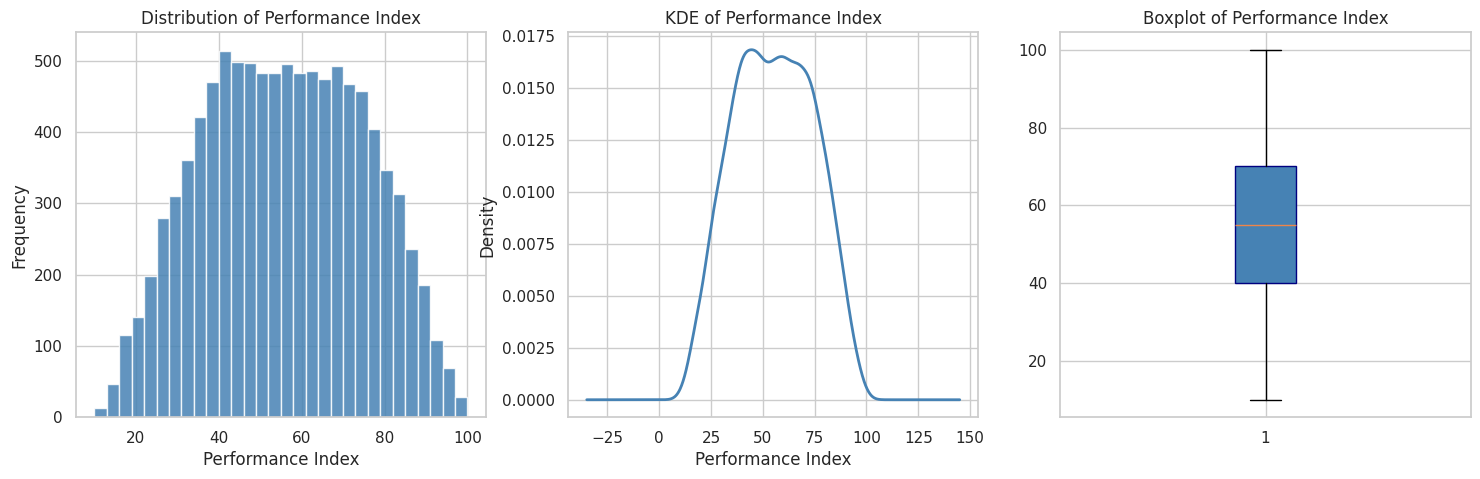

In [143]:
print("\n" + "="*60)
print("STEP 5: UNIVARIATE ANALYSIS — TARGET VARIABLE")
print("="*60)
 
target = 'Performance Index'
 
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
 
# Histogram
axes[0].hist(df[target], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title(f'Distribution of {target}')
axes[0].set_xlabel(target)
axes[0].set_ylabel('Frequency')

#KDE plot

df[traget].plot(kind = 'kde',ax=axes[1],color='steelblue',linewidth=2)
axes[1].set_title(f"KDE of {traget}")
axes[1].set_xlabel(traget)

#Box plot
axes[2].boxplot(df[target], vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', color='navy'))
axes[2].set_title(f'Boxplot of {traget}')


#   Skewness & Kurtosis

In [144]:
print(f"\nSkewness: {df[traget].skew()}")
print(f"\nKurtosis: {df[traget].kurt()}")
print(f"\nMean: {df[traget].mean()}")
print(f"\nMedian: {df[traget].median()}")
print(f"\nStd Dev : {df[traget].std()}")


Skewness: -0.00041186196091178305

Kurtosis: -0.8601253774528677

Mean: 55.2166514737162

Median: 55.0

Std Dev : 19.208570054616885


# **Univariate Analysis of Numerical Features**

In [145]:
numeric_cols =df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c!= traget]
print(f"Numeric feature columns: {numeric_cols}")

Numeric feature columns: ['Hours Studied', 'Previous Scores', 'Sleep Hours', 'Sample Question Papers Practiced']



Hours Studied:
  Min=1.00, Max=9.00, Mean=4.99, Skew=-0.003

Previous Scores:
  Min=40.00, Max=99.00, Mean=69.44, Skew=0.006

Sleep Hours:
  Min=4.00, Max=9.00, Mean=6.53, Skew=-0.041

Sample Question Papers Practiced:
  Min=0.00, Max=9.00, Mean=4.58, Skew=-0.035


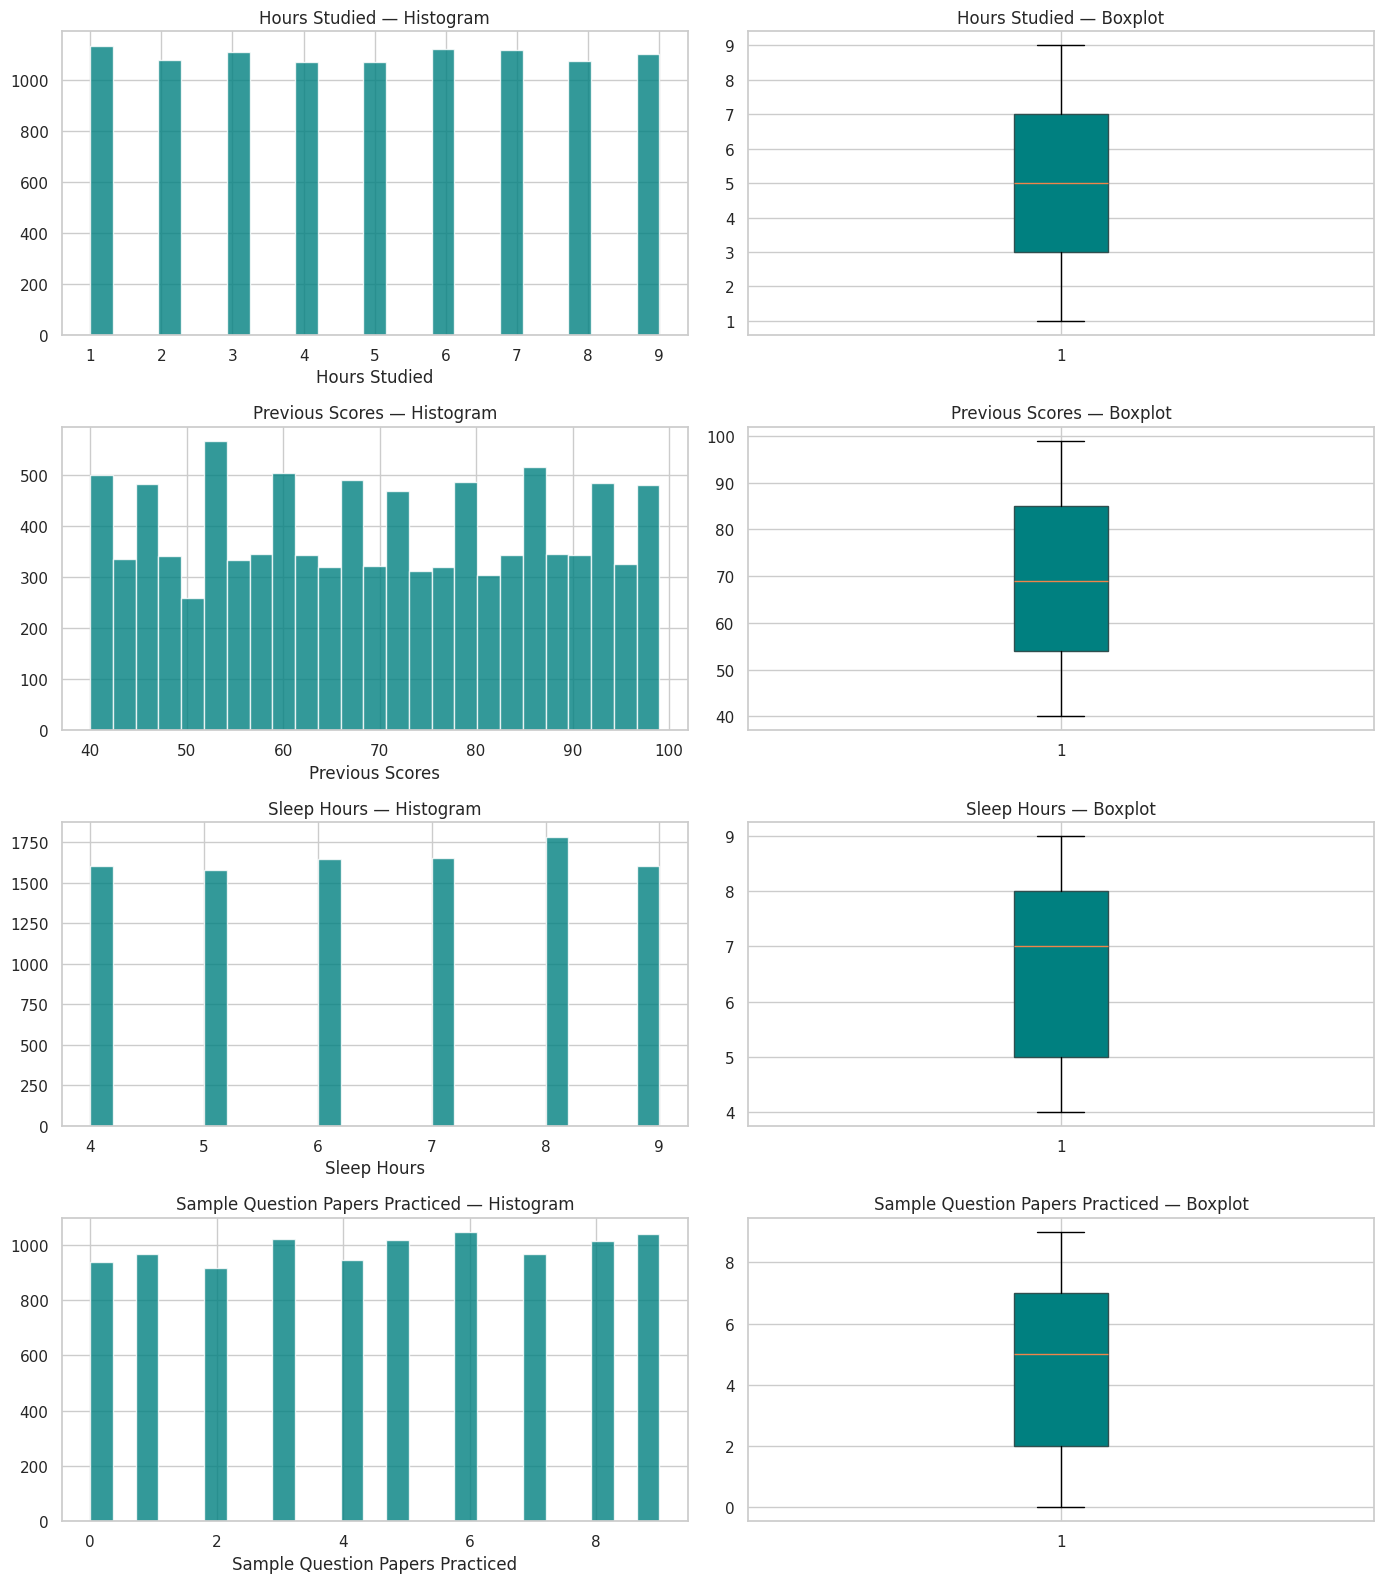

In [146]:

fig, axes = plt.subplots(len(numeric_cols), 2, figsize=(14, 4 * len(numeric_cols)))

for i, col in enumerate(numeric_cols):
    # Histogram
    axes[i, 0].hist(df[col], bins=25, color='teal', edgecolor='white', alpha=0.8)
    axes[i, 0].set_title(f'{col} — Histogram')
    axes[i, 0].set_xlabel(col)

    # ✅ Fixed boxplot — removed invalid 'darkteal'
    axes[i, 1].boxplot(df[col], vert=True, patch_artist=True,
                       boxprops=dict(facecolor='teal', color='darkslategray'))
    axes[i, 1].set_title(f'{col} — Boxplot')


 
    print(f"\n{col}:")
    print(f"  Min={df[col].min():.2f}, Max={df[col].max():.2f}, "
          f"Mean={df[col].mean():.2f}, Skew={df[col].skew():.3f}")
 
plt.tight_layout()



# Univariate Analysis of Categorical Features

Categorical Column:['Extracurricular Activities']

Extracurricular Activities distribution:
Extracurricular Activities
No     4986
Yes    4887
Name: count, dtype: int64


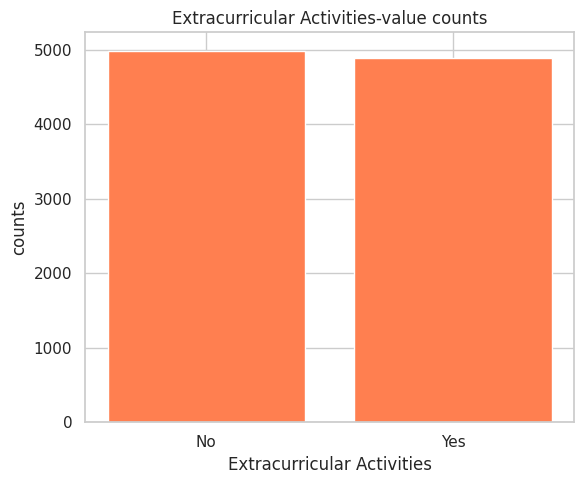

In [147]:
cat_cols= df.select_dtypes(include=['object']).columns.tolist()
print(f'Categorical Column:{cat_cols}')

if cat_cols:
    fig,axes=plt.subplots(1,len(cat_cols),figsize=(6*len(cat_cols),5))
    if len(cat_cols)==1:
        axes=[axes]

for i ,col in enumerate(cat_cols):
    counts = df[col].value_counts()
    axes[i].bar(counts.index,counts.values,color='coral',edgecolor='white')
    axes[i].set_title(f'{col}-value counts')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('counts')
    print(f"\n{col} distribution:\n{counts}")

plt.tight_layout()
        


# Bivariate Analysis — Features vs Target

Correlation of 'Hours Studied' with 'Performance Index': 0.3753
Correlation of 'Previous Scores' with 'Performance Index': 0.9151
Correlation of 'Sleep Hours' with 'Performance Index': 0.0504
Correlation of 'Sample Question Papers Practiced' with 'Performance Index': 0.0434


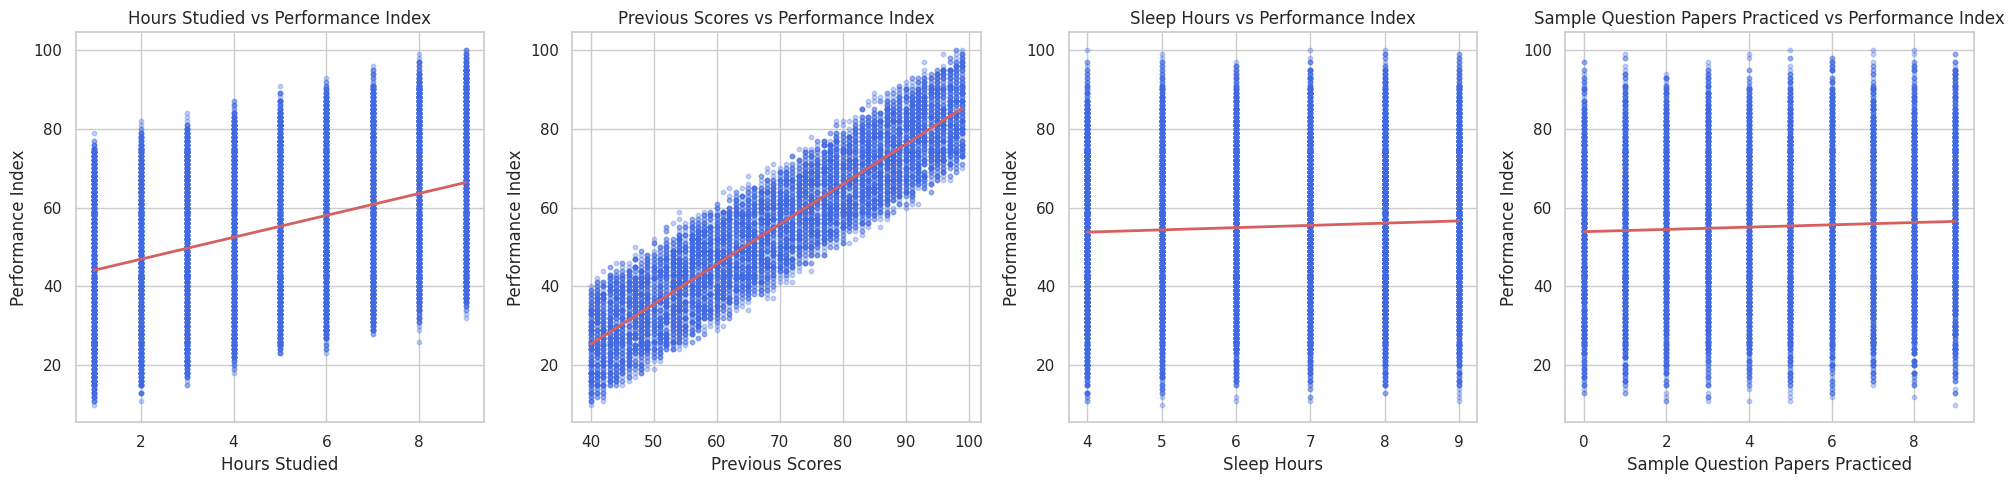

In [148]:
# Scatter plots: numeric features vs target

fig,axes = plt.subplots(1,len(numeric_cols),figsize=(5*len(numeric_cols),5))

if len(numeric_cols)==1:
    axes=[axes]
    
for i , col in enumerate(numeric_cols):
    axes[i].scatter(df[col],df[traget],alpha=0.3,color='royalblue',s=10)

    m,b = np.polyfit(df[col],df[traget],1)
    axes[i].plot(sorted(df[col]),[m * x+b for x in sorted(df[col])],'-r',linewidth=2)
    axes[i].set_title(f'{col} vs {traget}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel(traget)

    corr = df[col].corr(df[target])
    print(f"Correlation of '{col}' with '{target}': {corr:.4f}")
 
plt.tight_layout()
    

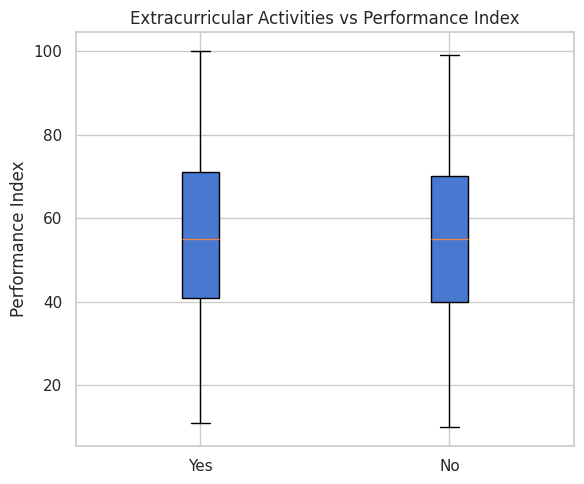

In [149]:
# Categorical vs Target — Box plots

if cat_cols:
    fig, axes = plt.subplots(1, len(cat_cols), figsize=(6 * len(cat_cols), 5))
    if len(cat_cols) == 1:
        axes = [axes]
    for i, col in enumerate(cat_cols):
        groups = [df[df[col] == v][target].values for v in df[col].unique()]
        axes[i].boxplot(groups, labels=df[col].unique(), patch_artist=True)
        axes[i].set_title(f'{col} vs {target}')
        axes[i].set_ylabel(target)
    plt.tight_layout()

# Correlation Analysis


Correlation with Target:
Performance Index                   1.000000
Previous Scores                     0.915135
Hours Studied                       0.375332
Sleep Hours                         0.050352
Sample Question Papers Practiced    0.043436
Extracurricular Activities          0.026075
Name: Performance Index, dtype: float64


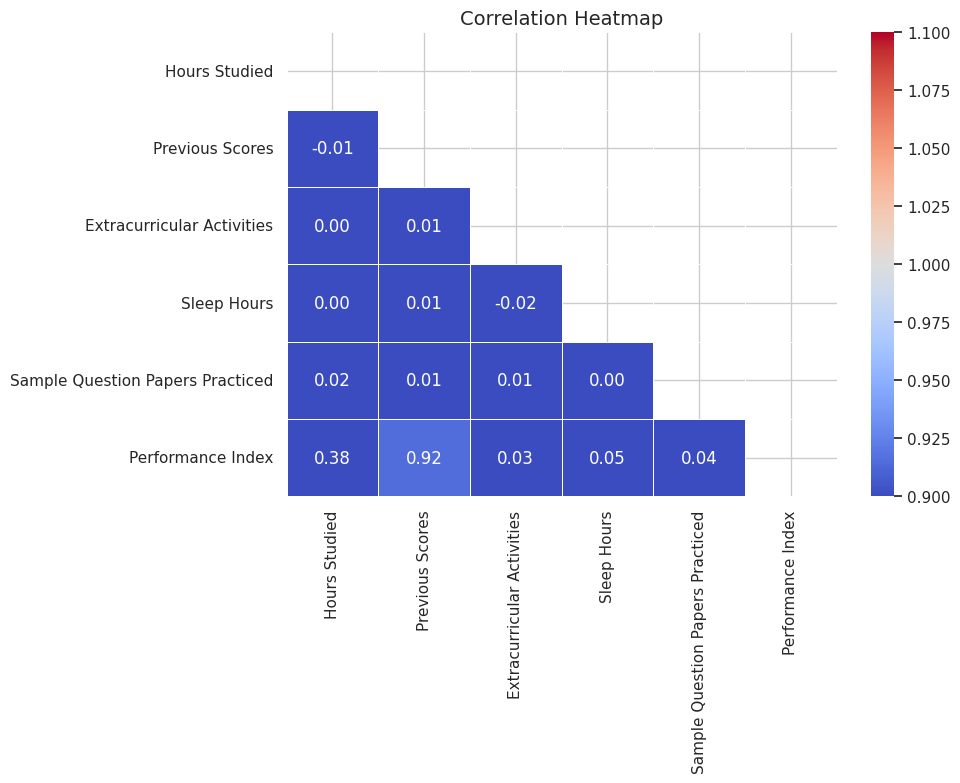

In [150]:
# Encode categoricals temporarily for correlation

df_corr =df.copy()
for col in cat_cols:
    df_corr[col] = LabelEncoder().fit_transform(df_corr[col])
    
corr_matrix = df_corr.corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix,dtype=bool))
sns.heatmap(corr_matrix,annot=True,fmt=".2f",cmap="coolwarm",
           mask=mask,vmin=1,vmax=1,linewidth=0.5)

plt.title("Correlation Heatmap",fontsize=14)
plt.tight_layout()
print("\nCorrelation with Target:")
print(corr_matrix[target].sort_values(ascending=False))

# Multivariate Analysis — Pairplot

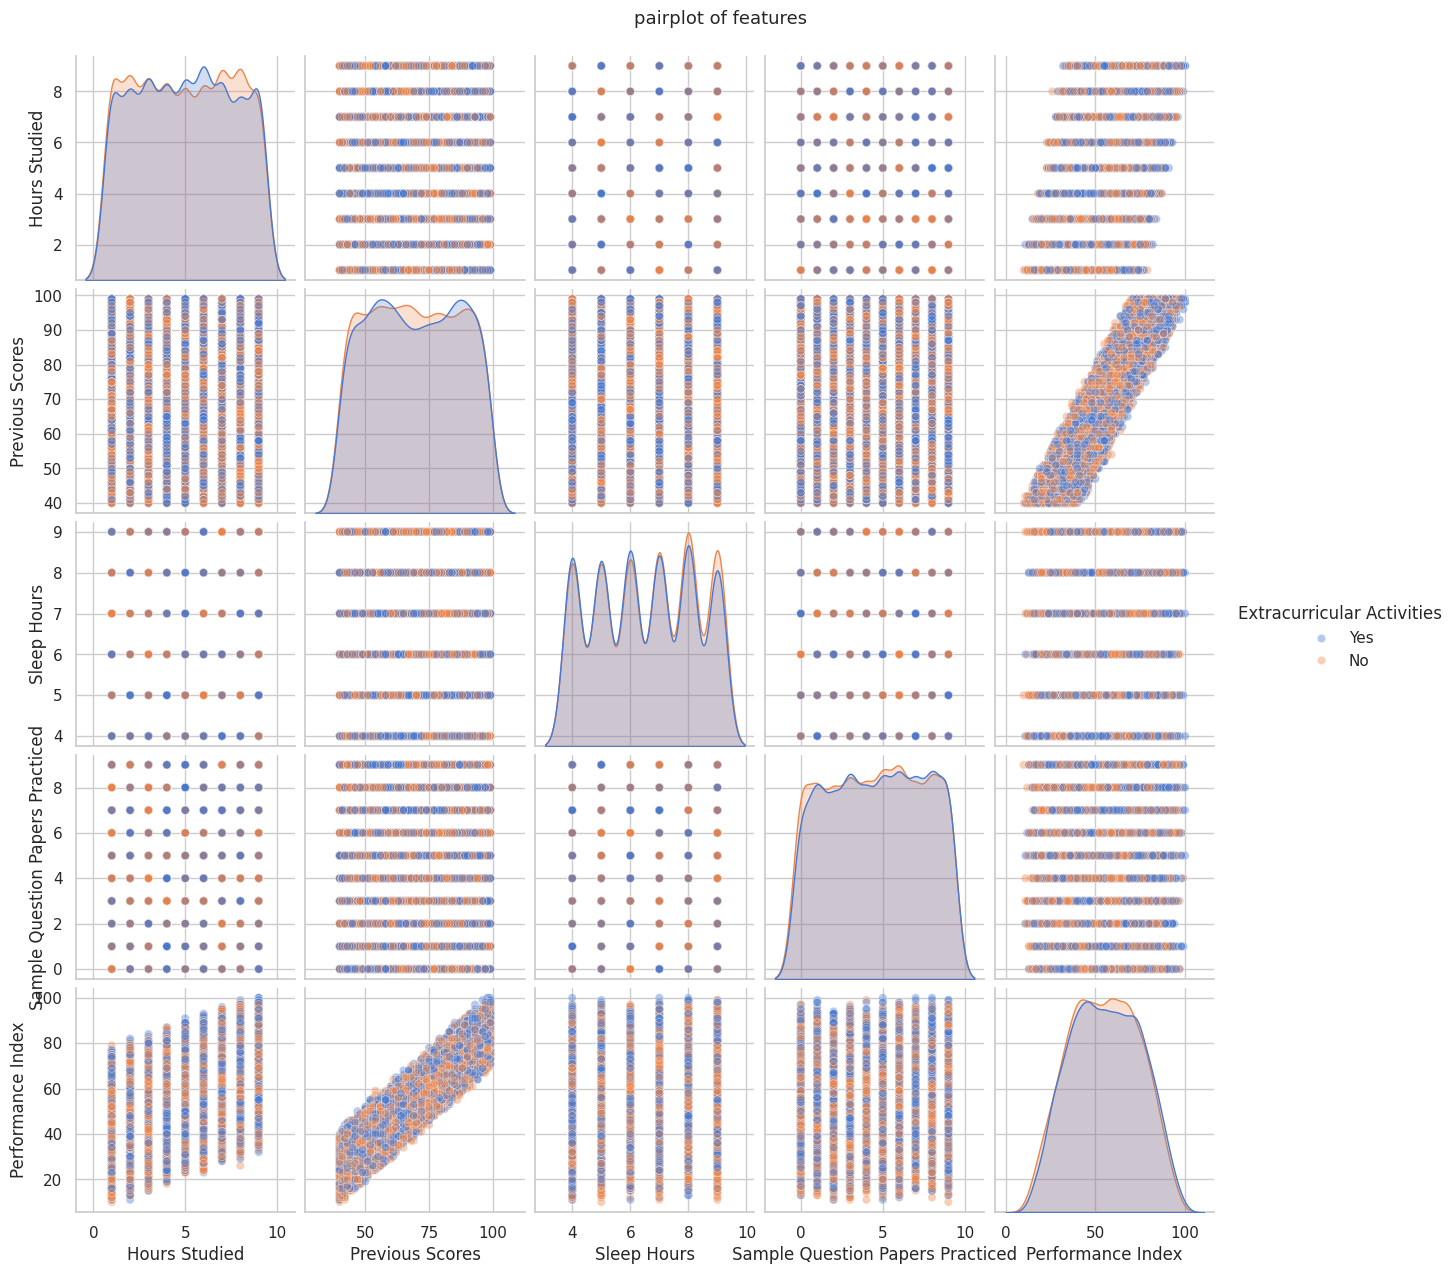

In [151]:
pair_cols = numeric_cols +[traget]

if cat_cols:
    hue_col = cat_cols[0]
    pairplot_df = df[pair_cols+[hue_col]]
    sns.pairplot(pairplot_df,hue=hue_col,plot_kws={'alpha':0.4},diag_kind='kde')
else:
    sns.pairplot(df[pair_cols],plot_kws={'alpha':0.4},diag_kind='kde')
    
plt.suptitle("pairplot of features",y=1.02,fontsize=13)
plt.show()

# Outlier Detection — IQR Method

Hours Studied: 0 outliers | Range [-3.00, 13.00]
Previous Scores: 0 outliers | Range [7.50, 131.50]
Sleep Hours: 0 outliers | Range [0.50, 12.50]
Sample Question Papers Practiced: 0 outliers | Range [-5.50, 14.50]
Performance Index: 0 outliers | Range [-5.00, 115.00]


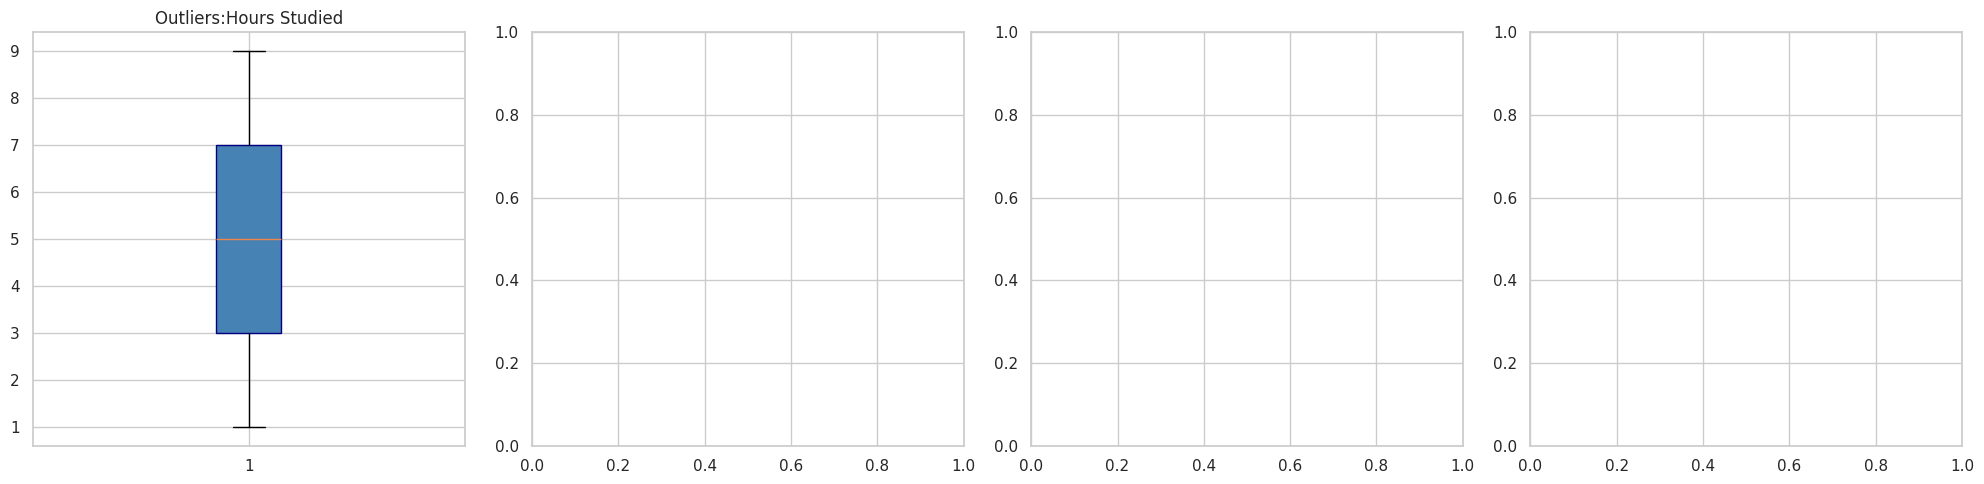

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

In [157]:
outlier_summary={}

for col in numeric_cols + [traget]:
    Q1= df[col].quantile(0.25)
    Q3= df[col].quantile(0.75)

    IQR = Q3-Q1
    lower = Q1-1.5*IQR
    upper = Q3+1.5*IQR
    outlier=df[(df[col]<lower) | (df[col]>upper)]
    outlier_summary[col]=len(outlier)
    print(f"{col}: {len(outlier)} outliers | Range [{lower:.2f}, {upper:.2f}]")

#visualize 
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(5 * len(numeric_cols), 5))
if len(numeric_cols)==1:
    axes=[axes]
    
for i,col in enumerate(numeric_cols):
    axes[i].boxplot(df[col],patch_artist=True,
                   boxprops=dict(facecolor='steelblue',color='navy'))
    axes[i].set_title(f'Outliers:{col}')
    plt.tight_layout()
    plt.show()


# Normality Test

Shapiro-Wilk → Statistic=0.9852, p-value=0.000000
 Target is NOT normally distributed 


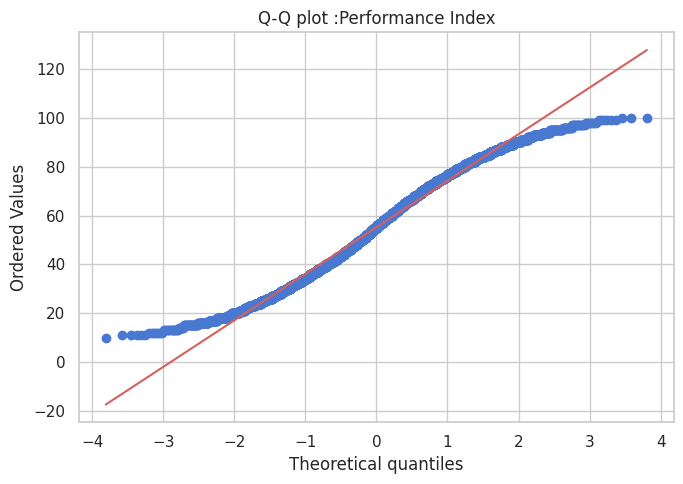

In [160]:
sample = df[traget].sample(min(5000, len(df)),random_state=42)
stat,p = stats.shapiro(sample)
print(f"Shapiro-Wilk → Statistic={stat:.4f}, p-value={p:.6f}")
if p >0.05:
        print("Target appears normally distributed")
else:
    print(" Target is NOT normally distributed ")
    
 #Q-Q plot
fig,ax=plt.subplots(figsize=(7,5))
stats.probplot(df[traget],dist="norm",plot=ax)
ax.set_title(f"Q-Q plot :{traget}")
plt.tight_layout()
plt.show()


